# ABI Longitudinal — Whole-Brain FC

Extends the baseline `ABI_BASELINE.ipynb` to work at **subject level** using all longitudinal visits.

**Three aggregation strategies**:
- `max_abi` — maximum ABI across all visits (flag if any scan is abnormal)
- `mean_abi` — mean ABI across all visits (stable longitudinal signal)
- `slope_abi` — OLS slope of ABI vs. normalised Δt (captures conversion trajectory)

The best aggregation is selected via 5-fold **subject-level** StratifiedGroupKFold CV (no same-subject leakage across folds).

Reference statistics are built from **training MCI baseline scans only** (same discipline as GELSTM).

In [1]:
import json, os, glob, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from scipy.stats import linregress
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
print('Imports OK')


Imports OK


## Configuration

In [2]:
WB_ROOT      = Path('/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v3__/matrices')
METADATA_DIR = Path('/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v4__/metadata')
# splits_gaae contains healthy/ad/mci/converter across train/val/test
SPLITS_GAAE_DIR = Path('/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v3__/metadata/splits_gaae')
SPLITS_GEC_DIR  = Path('/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v4__/metadata/splits_gec')

ABI_CHECKPOINT_DIR = Path('/mnt/e/fyassine/ad-early-detection/DCI/notebooks/checkpoints_abi_longitudinal')
ABI_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

ABI_OUTPUT_DIR = Path('/mnt/e/fyassine/ad-early-detection/ABI/outputs')
ABI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FILE_SUFFIX  = '_whole_brain_correlation_matrix_z_transformed.npz'
Z_THRESHOLD  = 3.0
N_FOLDS      = 5
RANDOM_STATE = 42
STD_FLOOR    = 1e-6

print(f'Matrices root: {WB_ROOT}')
print(f'Z_THRESHOLD:   {Z_THRESHOLD}')
print(f'ABI output dir: {ABI_OUTPUT_DIR}')


Matrices root: /mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v3__/matrices
Z_THRESHOLD:   3.0
ABI output dir: /mnt/e/fyassine/ad-early-detection/ABI/outputs


## Load Splits

In [3]:
# splits_gaae contains all 4 diagnosis groups (healthy, ad, mci, converter)
# split across the same train/val/test as the GAAE model.
# We use:
#   - splits_gaae/train.csv healthy  → ABI reference (no leakage from val/test)
#   - splits_gec train+val mci/converter → CV pool
#   - splits_gec test       mci/converter → holdout

allowed_mci = {'converter', 'mci'}

# Load healthy train subjects for reference
gaae_train = pd.read_csv(SPLITS_GAAE_DIR / 'train.csv')
gaae_train['Repseudonym'] = gaae_train['Repseudonym'].astype(str)
gaae_train['diagnosis']   = gaae_train['diagnosis'].astype(str).str.lower().str.strip()
healthy_train_ids = set(
    gaae_train[gaae_train['diagnosis'] == 'healthy']['Repseudonym']
)
print(f'Healthy subjects in train split: {len(healthy_train_ids)}')

# Load mci/converter splits for CV and test
split_frames = {}
for name in ['train', 'val', 'test']:
    df = pd.read_csv(SPLITS_GEC_DIR / f'{name}.csv')
    df['Repseudonym'] = df['Repseudonym'].astype(str)
    df['diagnosis']   = df['diagnosis'].astype(str).str.lower().str.strip()
    df = df[df['diagnosis'].isin(allowed_mci)].copy()
    df['converter_status'] = (df['diagnosis'] == 'converter').astype(int)
    split_frames[name] = df

for name, df in split_frames.items():
    print(f"{name}: {df['Repseudonym'].nunique()} MCI/converter subjects, "
          f"{df['diagnosis'].value_counts().to_dict()}")


Healthy subjects in train split: 150
train: 86 MCI/converter subjects, {'converter': 43, 'mci': 43}
val: 16 MCI/converter subjects, {'converter': 8, 'mci': 8}
test: 14 MCI/converter subjects, {'mci': 7, 'converter': 7}


## Discover Files & Build Subject Visit Lists

Each subject may have files at multiple timepoints (M0, M12, M24 …). Files are sorted by the integer month suffix in their filename.

In [4]:
def extract_month(fname):
    """Extract month integer from filename like 'sub-XXX_ses-M12_...'."""
    import re
    m = re.search(r'_M(\d+)_', fname)  # correct: matches ses-01_M12_...
    return int(m.group(1)) if m else 0

all_npz = sorted(f for f in os.listdir(WB_ROOT)
                 if f.endswith(FILE_SUFFIX) and f.startswith('sub-'))

# file_index: sid → [(month, filename), ...] sorted by month
file_index = {}
for fname in all_npz:
    sid = fname.split('_')[0].replace('sub-', '')
    file_index.setdefault(sid, []).append((extract_month(fname), fname))
for sid in file_index:
    file_index[sid].sort(key=lambda x: x[0])

print(f'Total npz files: {len(all_npz)}')
print(f'Unique subjects: {len(file_index)}')


Total npz files: 1186
Unique subjects: 842


In [5]:
def load_matrix(fname):
    data = np.load(WB_ROOT / fname)
    key  = 'array' if 'array' in data else list(data.keys())[0]
    return data[key].astype(np.float64)

sample_mat = load_matrix(all_npz[0])
N_ROIS = sample_mat.shape[0]
print(f'Matrix shape: {sample_mat.shape}')


Matrix shape: (200, 200)


## Build ABI Reference from Train MCI Baseline Scans

Uses only the **earliest available scan** (M0) from **training MCI (stable)** subjects to build the normative reference.

**Why MCI, not healthy?**  
The ABI here measures *deviation from the stable-MCI baseline* — i.e. how much a subject's FC deviates from a patient who will *not* convert. Converters deviate more from this MCI reference because they are further along the MCI→AD spectrum. Using healthy subjects as reference instead makes **both** MCI and converters look abnormal (they are both non-healthy), and stable MCI subjects who survive longer follow-up accumulate more 'healthy deviation' over time, systematically inverting the AUC.

In [6]:
# Reference: baseline scans of training MCI (stable) subjects only.
# Using the EARLIEST visit for each MCI subject prevents temporal leakage.

train_mci_ids = set(
    split_frames['train']
    .loc[split_frames['train']['diagnosis'] == 'mci', 'Repseudonym']
    .astype(str)
)
print(f'Train MCI subjects for reference: {len(train_mci_ids)}')

ref_matrices = []
for sid in sorted(train_mci_ids):
    visits = file_index.get(sid, [])
    if visits:
        ref_matrices.append(load_matrix(visits[0][1]))  # baseline visit only

if not ref_matrices:
    raise RuntimeError('No reference matrices found for train MCI subjects.')

ref_stack = np.stack(ref_matrices, axis=0)
ref_mean  = np.mean(ref_stack, axis=0)
ref_std   = np.std(ref_stack,  axis=0, ddof=1)
np.fill_diagonal(ref_mean, 0.0)
np.fill_diagonal(ref_std,  1.0)
ref_std   = np.clip(ref_std, STD_FLOOR, None)

print(f'Reference built from {len(ref_matrices)} MCI baseline matrices')
print(f'ref_mean range: [{ref_mean.min():.4f}, {ref_mean.max():.4f}]')
print(f'ref_std  range: [{ref_std.min():.6f}, {ref_std.max():.4f}]')


Train MCI subjects for reference: 43
Reference built from 43 MCI baseline matrices
ref_mean range: [-0.4029, 0.9880]
ref_std  range: [0.110471, 1.0000]


## Compute Per-Visit ABI & Subject-Level Features

For each visit's FC matrix:
1. Z-score: `(F - ref_mean) / ref_std`
2. Count connections where `|z| > Z_THRESHOLD` per ROI
3. ABI = mean over ROIs

**Subject-level features** (visit-count unbiased):
- `abi_baseline` — ABI at the **earliest** (M0) visit only  
  → measures static disease burden at study entry
- `abi_last` — ABI at the **latest** available visit  
  → measures disease burden at end of follow-up
- `abi_delta` — `abi_last − abi_baseline`  
  → captures progression direction (converters start higher, may plateau)

> **Why not max/mean?**  
> `max()` is biased by visit count: subjects with 6 visits have 6 chances for a high-ABI outlier. Stable MCI subjects stay in follow-up longer (they don't convert), so they systematically accumulate higher max-ABI than early-converting subjects, **inverting the AUC to 0.35**.


In [7]:
import re

def compute_abi(mat):
    z  = (mat - ref_mean) / ref_std
    z  = np.nan_to_num(z, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(z, 0.0)
    return np.mean(np.sum(np.abs(z) > Z_THRESHOLD, axis=1))

all_subjects_df = pd.concat(split_frames.values(), ignore_index=True)
all_subjects_df = all_subjects_df.drop_duplicates('Repseudonym', keep='first')

records = []
session_records = []
for _, row in all_subjects_df.iterrows():
    sid    = str(row['Repseudonym'])
    visits = file_index.get(sid, [])
    if not visits:
        continue

    abis = []
    for month, fname in visits:
        abi_val = compute_abi(load_matrix(fname))
        abis.append(abi_val)
        ses_match = re.search(r'(ses-\d+)', fname)
        ses_label = ses_match.group(1) if ses_match else f'ses-M{month}'
        session_records.append(['sub-' + sid, ses_label, Z_THRESHOLD, sid, float(abi_val)])
    abis = np.array(abis)

    abi_baseline = float(abis[0])           # earliest visit
    abi_last     = float(abis[-1])           # most recent visit
    abi_delta    = abi_last - abi_baseline   # longitudinal change

    records.append({
        'subject_id':       sid,
        'diagnosis':        row['diagnosis'],
        'converter_status': int(row['converter_status']),
        'n_visits':         len(visits),
        'abi_baseline':     abi_baseline,
        'abi_last':         abi_last,
        'abi_delta':        abi_delta,
    })

subj_df = pd.DataFrame(records)
print(f'Subjects with data: {len(subj_df)}')
print(f'Total session records: {len(session_records)}')
print()
for feat in ['abi_baseline','abi_last','abi_delta']:
    g = subj_df.groupby('diagnosis')[feat].agg(['mean','std'])
    print(f'{feat}:')
    print(g.to_string())
    print()


Subjects with data: 116
Total session records: 364

abi_baseline:
               mean       std
diagnosis                    
converter  1.307931  2.492646
mci        0.519138  0.690967

abi_last:
               mean       std
diagnosis                    
converter  0.974310  0.669703
mci        2.499483  4.966523

abi_delta:
               mean       std
diagnosis                    
converter -0.333621  2.574016
mci        1.980345  4.931347



In [8]:
train_ids = set(split_frames['train']['Repseudonym'].astype(str))
val_ids   = set(split_frames['val']['Repseudonym'].astype(str))
test_ids  = set(split_frames['test']['Repseudonym'].astype(str))

def get_split(sid):
    if sid in test_ids: return 'test'
    if sid in val_ids:  return 'val'
    if sid in train_ids: return 'train'
    return 'unknown'

subj_df['split'] = subj_df['subject_id'].apply(get_split)
cv_df   = subj_df[subj_df['split'].isin(['train','val'])].reset_index(drop=True)
test_df = subj_df[subj_df['split'] == 'test'].reset_index(drop=True)

print(f'CV pool: {len(cv_df)} subjects  '
      f"({cv_df['converter_status'].sum()} converters)")
print(f'Test:    {len(test_df)} subjects  '
      f"({test_df['converter_status'].sum()} converters)")


CV pool: 102 subjects  (51 converters)
Test:    14 subjects  (7 converters)


## 5-Fold Subject-Level Cross-Validation

In [9]:
FEATURES = ['abi_baseline', 'abi_last', 'abi_delta']

all_cv = {feat: {'fold':[],'val_auc':[],'val_sensitivity':[],
                  'val_specificity':[],'val_f1':[],'best_threshold':[]} for feat in FEATURES}
oof_probs_all = {feat: np.zeros(len(cv_df)) for feat in FEATURES}
y_cv = cv_df['converter_status'].values
groups_cv = cv_df['subject_id'].values

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS)

for fold, (tr_idx, va_idx) in enumerate(sgkf.split(cv_df, y_cv, groups=groups_cv)):
    print(f'\nFold {fold+1}/{N_FOLDS}  train={len(tr_idx)}  val={len(va_idx)}')
    y_tr, y_va = y_cv[tr_idx], y_cv[va_idx]

    for feat in FEATURES:
        x_tr = cv_df[feat].values[tr_idx]
        x_va = cv_df[feat].values[va_idx]

        if len(np.unique(y_va)) < 2:
            auc_v = 0.5
            best_thr, sens, spec, f1v = 0.0, 0.0, 0.0, 0.0
        else:
            fpr_, tpr_, thrs_ = roc_curve(y_va, x_va)
            auc_v = roc_auc_score(y_va, x_va)
            best_idx = np.argmax(tpr_ - fpr_)
            best_thr = float(thrs_[best_idx])
            preds = (x_va >= best_thr).astype(int)
            cm = confusion_matrix(y_va, preds, labels=[0,1])
            tn,fp,fn,tp = cm.ravel() if cm.size==4 else (0,0,0,0)
            sens = tp/(tp+fn+1e-9)
            spec = tn/(tn+fp+1e-9)
            f1v  = f1_score(y_va, preds, zero_division=0)

        oof_probs_all[feat][va_idx] = x_va
        all_cv[feat]['fold'].append(fold+1)
        all_cv[feat]['val_auc'].append(auc_v)
        all_cv[feat]['val_sensitivity'].append(sens)
        all_cv[feat]['val_specificity'].append(spec)
        all_cv[feat]['val_f1'].append(f1v)
        all_cv[feat]['best_threshold'].append(best_thr)

    # Print fold summary
    fold_aucs = '  '.join(f'{feat}={all_cv[feat]["val_auc"][-1]:.3f}' for feat in FEATURES)
    print(f'  AUC: {fold_aucs}')



Fold 1/5  train=81  val=21
  AUC: abi_baseline=0.791  abi_last=0.314  abi_delta=0.241

Fold 2/5  train=82  val=20
  AUC: abi_baseline=0.905  abi_last=0.410  abi_delta=0.180

Fold 3/5  train=82  val=20
  AUC: abi_baseline=0.810  abi_last=0.260  abi_delta=0.170

Fold 4/5  train=82  val=20
  AUC: abi_baseline=0.930  abi_last=0.670  abi_delta=0.335

Fold 5/5  train=81  val=21
  AUC: abi_baseline=0.864  abi_last=0.455  abi_delta=0.227


## CV Summary & Best Feature Selection

In [10]:
print('CV Summary (mean ± std across 5 folds):')
print('=' * 70)
print(f"{'Feature':<12} {'AUC':>10} {'Sens':>10} {'Spec':>10} {'F1':>10}")
print('-' * 70)
best_feat, best_cv_auc = None, 0.0
for feat in FEATURES:
    aucs = np.array(all_cv[feat]['val_auc'])
    sens = np.array(all_cv[feat]['val_sensitivity'])
    spec = np.array(all_cv[feat]['val_specificity'])
    f1s  = np.array(all_cv[feat]['val_f1'])
    print(f"{feat:<12} {aucs.mean():>7.4f}±{aucs.std():<4.4f} "
          f"{sens.mean():>7.4f}±{sens.std():<4.4f} "
          f"{spec.mean():>7.4f}±{spec.std():<4.4f} "
          f"{f1s.mean():>7.4f}±{f1s.std():<4.4f}")
    if aucs.mean() > best_cv_auc:
        best_cv_auc = aucs.mean()
        best_feat   = feat

print(f'\n→  Best feature: {best_feat}  (CV AUC = {best_cv_auc:.4f})')

# Threshold for best feature: median Youden from folds
ACTIVE_THRESHOLD = float(np.median(all_cv[best_feat]['best_threshold']))
print(f'   Median Youden threshold: {ACTIVE_THRESHOLD:.4f}')

# OOF AUC for best feature
oof_probs = oof_probs_all[best_feat]
oof_auc   = roc_auc_score(y_cv, oof_probs) if len(np.unique(y_cv)) > 1 else 0.0
print(f'   OOF AUC: {oof_auc:.4f}')


CV Summary (mean ± std across 5 folds):
Feature             AUC       Sens       Spec         F1
----------------------------------------------------------------------
abi_baseline  0.8599±0.0533  0.9200±0.0400  0.7836±0.0990  0.8635±0.0187
abi_last      0.4216±0.1419  0.9600±0.0800  0.2964±0.2116  0.7233±0.0253
abi_delta     0.2306±0.0587  0.2000±0.4000  0.8200±0.3600  0.1419±0.2839

→  Best feature: abi_baseline  (CV AUC = 0.8599)
   Median Youden threshold: 0.5500
   OOF AUC: 0.8545


## Test-Set Evaluation

In [11]:
y_te    = test_df['converter_status'].values
te_pred_raw = test_df[best_feat].values
te_preds    = (te_pred_raw >= ACTIVE_THRESHOLD).astype(int)

te_auc  = roc_auc_score(y_te, te_pred_raw) if len(np.unique(y_te)) > 1 else 0.0
cm_te   = confusion_matrix(y_te, te_preds, labels=[0,1])
tn,fp,fn,tp = cm_te.ravel() if cm_te.size == 4 else (0,0,0,0)
te_sens = tp/(tp+fn+1e-9)
te_spec = tn/(tn+fp+1e-9)
te_f1   = f1_score(y_te, te_preds, zero_division=0)

print(f'Test AUC={te_auc:.4f}  Sens={te_sens:.4f}  Spec={te_spec:.4f}  F1={te_f1:.4f}')
print()
print(classification_report(y_te, te_preds, target_names=['stable_mci','converter']))


Test AUC=0.3673  Sens=0.8571  Spec=0.1429  F1=0.6316

              precision    recall  f1-score   support

  stable_mci       0.50      0.14      0.22         7
   converter       0.50      0.86      0.63         7

    accuracy                           0.50        14
   macro avg       0.50      0.50      0.43        14
weighted avg       0.50      0.50      0.43        14



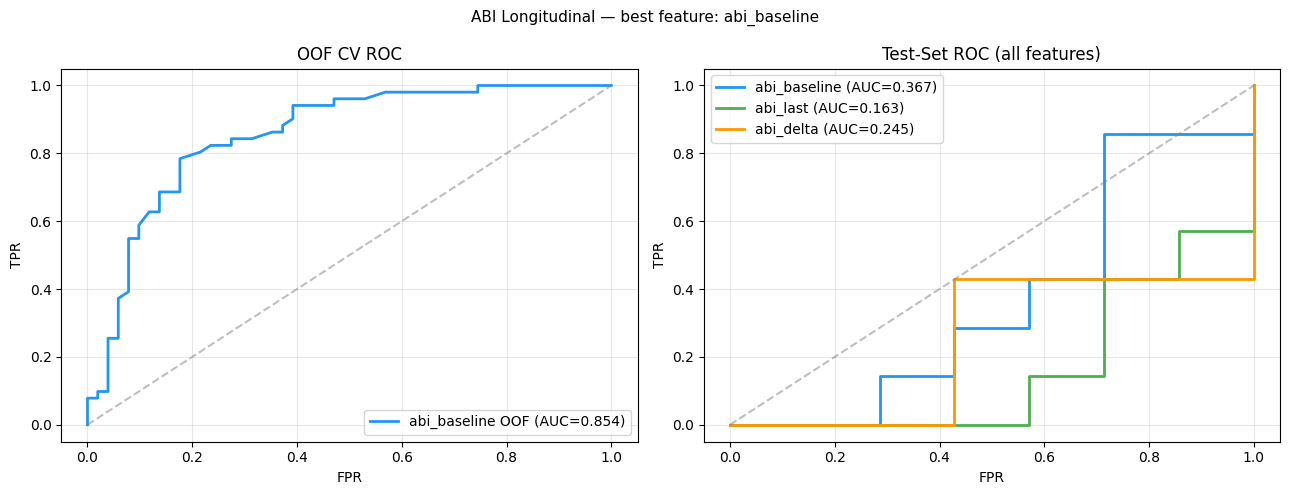

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {'abi_baseline':'#2196F3', 'abi_last':'#4CAF50', 'abi_delta':'#FF9800'}

ax = axes[0]
fpr_oof, tpr_oof, _ = roc_curve(y_cv, oof_probs)
ax.plot(fpr_oof, tpr_oof, lw=2, color=colors[best_feat],
        label=f'{best_feat} OOF (AUC={oof_auc:.3f})')
ax.plot([0,1],[0,1],'--',color='grey',alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('OOF CV ROC')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for feat in FEATURES:
    fpr_t, tpr_t, _ = roc_curve(y_te, test_df[feat].values)
    auc_t = roc_auc_score(y_te, test_df[feat].values)
    ax.plot(fpr_t, tpr_t, lw=2, color=colors[feat], label=f'{feat} (AUC={auc_t:.3f})')
ax.plot([0,1],[0,1],'--',color='grey',alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Test-Set ROC (all features)')
ax.legend(); ax.grid(alpha=0.3)

fig.suptitle(f'ABI Longitudinal — best feature: {best_feat}', fontsize=11)
plt.tight_layout(); plt.show()


## Save Results

In [13]:
run_timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
run_name      = f'abi_long_{run_timestamp}'
run_dir       = ABI_CHECKPOINT_DIR / run_name
run_dir.mkdir(parents=True, exist_ok=True)

subj_df.to_csv(run_dir / 'subject_abi.csv', index=False)

run_summary = {
    'run_name':         run_name,
    'z_threshold':      Z_THRESHOLD,
    'n_folds':          N_FOLDS,
    'random_state':     RANDOM_STATE,
    'n_rois':           int(N_ROIS),
    'best_feature':     best_feat,
    'active_threshold': float(ACTIVE_THRESHOLD),
    'cv_results':       all_cv[best_feat],
    'all_cv_results':   {f: {k: list(map(float, v)) for k,v in all_cv[f].items() if k!='fold'}
                         for f in FEATURES},
    'test_auc':           float(te_auc),
    'test_sensitivity':   float(te_sens),
    'test_specificity':   float(te_spec),
    'test_f1':            float(te_f1),
    'test_probabilities': te_pred_raw.tolist(),
    'test_labels':        y_te.tolist(),
}
with open(run_dir / 'run_summary.json', 'w') as _f:
    json.dump(run_summary, _f, indent=2)
print(f'Saved checkpoint to {run_dir}')

# Save per-session ABI in dci_scripts format
ses_df = pd.DataFrame(session_records,
                      columns=['Subject', 'Session', 'Threshold', 'Subject_Label', 'ABI'])
ses_df = ses_df.sort_values(by=['Subject', 'Session']).reset_index(drop=True)
out_csv = ABI_OUTPUT_DIR / f'ABI_all_subjects_th_{Z_THRESHOLD}_Delcode.csv'
ses_df.to_csv(out_csv, index=False)
print(f'Per-session ABI saved → {out_csv}  ({len(ses_df)} rows)')


Saved checkpoint to /mnt/e/fyassine/ad-early-detection/DCI/notebooks/checkpoints_abi_longitudinal/abi_long_2026-05-18_17-45-00
Per-session ABI saved → /mnt/e/fyassine/ad-early-detection/ABI/outputs/ABI_all_subjects_th_3.0_Delcode.csv  (364 rows)
